In [1]:
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from CamVidDataset import CamVidDataset
import pandas as pd
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

df = pd.read_csv('./CamVid/class_dict.csv')
class_colors = [(row.r, row.g, row.b) for _, row in df.iterrows()]

train_transform = A.Compose([
    A.Resize(height=512, width=512, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.7),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.2, rotate_limit=15, border_mode=cv2.BORDER_CONSTANT, value = 0, mask_value = 0, p = 0.5),
    A.Normalize(mean = (0.485, 0.456, 0.406), std = (0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(height=512, width=512, p = 1.0),
    A.Normalize(mean = (0.485, 0.456, 0.406), std = (0.229, 0.224, 0.225)),
    ToTensorV2()
])

train_dataset = CamVidDataset(image_dir="./CamVid/train", mask_dir="./CamVid/train_labels", class_colors = class_colors, transform = train_transform)
val_dataset = CamVidDataset(image_dir="./CamVid/val", mask_dir="./CamVid/val_labels", class_colors = class_colors, transform = val_transform)

batch_size = 4
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

c:\Projects\Computer Vision\Semantic Segmentation - Autonomous Driving\AutoDriving\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Projects\Computer Vision\Semantic Segmentation - Autonomous Driving\AutoDriving\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\rishd\AppData\Local\Temp\ipykernel_12956\446235439.py:18: UserWarning: Argument(s) 'value, mask_value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.2, rotate_limit=15, border_mode=cv2.BORDER_CONSTANT, value = 0, mask_value = 0, p = 0.5),


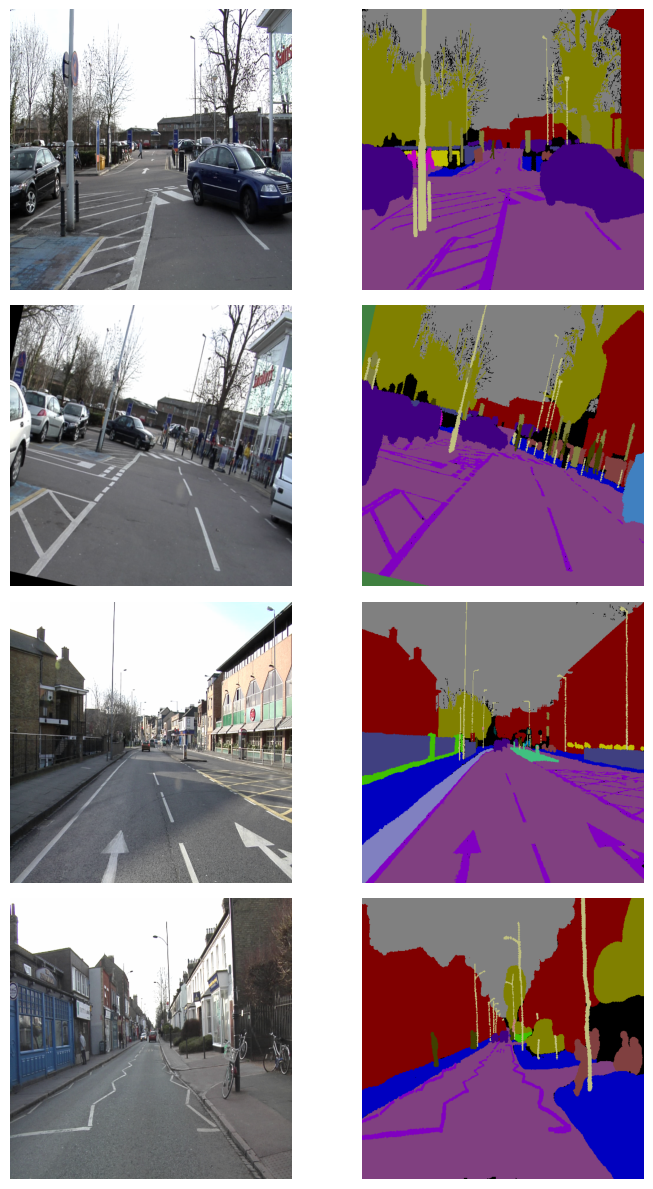

In [2]:
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
color_array = np.array(class_colors, dtype = np.uint8)

images, masks = next(iter(train_loader))

fig, axes = plt.subplots(batch_size, 2, figsize = (8, batch_size * 3))

for i in range(batch_size):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)

    colored_mask = color_array[masks[i].numpy()]

    axes[i, 0].imshow(img)
    axes[i, 0].axis("off")
    axes[i, 1].imshow(colored_mask)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [3]:
import segmentation_models_pytorch as smp

model = smp.Unet(encoder_name="mobilenet_v2", encoder_weights="imagenet", in_channels=3, classes=len(class_colors))
print(model)

Unet(
  (encoder): MobileNetV2Encoder(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kernel_size=(1

In [4]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

model.eval()

inputs, masks = next(iter(train_loader))
inputs, masks = inputs.to(device), masks.to(device)

with torch.no_grad():
    outputs = model(inputs)

print(f"Input Shape: {images.shape}")
print(f"Output Shape: {outputs.shape}")

cpu
Input Shape: torch.Size([4, 3, 512, 512])
Output Shape: torch.Size([4, 32, 512, 512])


In [5]:
preds = torch.argmax(outputs, dim = 1)
print(preds)

tensor([[[14, 19, 24,  ..., 29, 29, 25],
         [14,  5, 16,  ..., 21, 21, 21],
         [29,  5,  6,  ..., 24,  7, 24],
         ...,
         [29, 29, 29,  ...,  7,  9, 24],
         [29, 25,  7,  ..., 25,  6, 24],
         [29,  2,  2,  ...,  6, 21, 21]],

        [[ 6, 29, 24,  ..., 14, 21, 14],
         [29, 29, 29,  ..., 24,  6, 24],
         [29,  7, 29,  ..., 24,  6, 14],
         ...,
         [29,  6, 30,  ..., 29, 29, 21],
         [29, 13, 30,  ...,  7, 25, 21],
         [29,  2,  2,  ..., 21, 21, 21]],

        [[19, 26, 24,  ..., 14, 21, 14],
         [31, 14,  6,  ...,  9,  6, 21],
         [29, 14,  6,  ..., 21,  6, 21],
         ...,
         [29,  7,  7,  ...,  7, 29, 14],
         [29,  7,  7,  ..., 29, 29, 21],
         [29,  2,  2,  ..., 21, 21, 21]],

        [[29,  5, 11,  ..., 21, 21, 14],
         [24, 29,  7,  ..., 21,  6, 21],
         [29, 29, 24,  ..., 21, 21, 21],
         ...,
         [29,  7, 29,  ..., 29, 25, 21],
         [13, 25, 30,  ..., 25, 25, 

In [6]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

ce_loss = nn.CrossEntropyLoss()
dice_loss = smp.losses.DiceLoss(mode = 'multiclass')

def combined_loss(logits, targets):
    return ce_loss(logits, targets) + dice_loss(logits, targets)

In [7]:
def compute_iou(predictions, targets , num_classes):
    ious = []

    for cls in range(num_classes):
        pred_mask = (predictions == cls)
        target_mask = (targets == cls)

        intersection = (pred_mask & target_mask).sum().item()
        union = (pred_mask | target_mask).sum().item()

        ious.append(intersection / (union + 1e-6))

    miou = sum(ious) / num_classes
    return ious, miou

In [8]:
from tqdm import tqdm

def train_one_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0

    for batch in tqdm(dataloader):
        images, masks = batch
        images, masks = images.to(device), masks.to(device).long()

        optimizer.zero_grad()
        outputs = model(images)
        loss_l = loss_fn(outputs, masks)
        loss_l.backward()
        optimizer.step()

        total_loss += loss_l.item()

    return (total_loss / len(dataloader))


def validate(model, dataloader, loss_fn, device, num_classes):
    model.eval()
    total_loss = 0.0
    total_miou = 0.0
    with torch.no_grad():
        for batch in tqdm(dataloader):
            images, masks = batch
            images, masks = images.to(device), masks.to(device).long()

            outputs = model(images)
            loss_l = loss_fn(outputs, masks)
            total_loss += loss_l.item()
            preds = outputs.argmax(dim = 1)
            _, miou = compute_iou(preds, masks, num_classes)
            total_miou += miou
    return total_loss / len(dataloader), total_miou / len(dataloader)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = model.to(device)
num_epochs = 30
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
best_miou = 0.0

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, combined_loss, device)
    val_loss, val_miou = validate(model, val_loader, combined_loss, device, len(class_colors))
    print(f"Epoch {epoch + 1}/{num_epochs} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | mIoU: {val_miou:.4f}")

    if val_miou > best_miou:
        best_miou = val_miou
        torch.save(model.state_dict(), "best_model.pth")
        print(f"----> Saved Best Model (mIoU: {best_miou:.4f})")

    scheduler.step()


cuda


  0%|          | 0/93 [00:00<?, ?it/s]

100%|██████████| 25/25 [00:35<00:00,  1.41s/it]


Epoch 1/30 | train_loss: 3.1600 | val_loss: 2.3421 | mIoU: 0.1296
----> Saved Best Model (mIoU: 0.1296)


100%|██████████| 25/25 [00:35<00:00,  1.42s/it]


...

Epoch 28/30 | train_loss: 0.7941 | val_loss: 0.8943 | mIoU: 0.2684
----> Saved Best Model (mIoU: 0.2684)


100%|██████████| 25/25 [00:35<00:00,  1.41s/it]


Epoch 29/30 | train_loss: 0.7956 | val_loss: 0.8962 | mIoU: 0.2621


100%|██████████| 25/25 [00:35<00:00,  1.40s/it]

Epoch 30/30 | train_loss: 0.7933 | val_loss: 0.8915 | mIoU: 0.2706
----> Saved Best Model (mIoU: 0.2706)


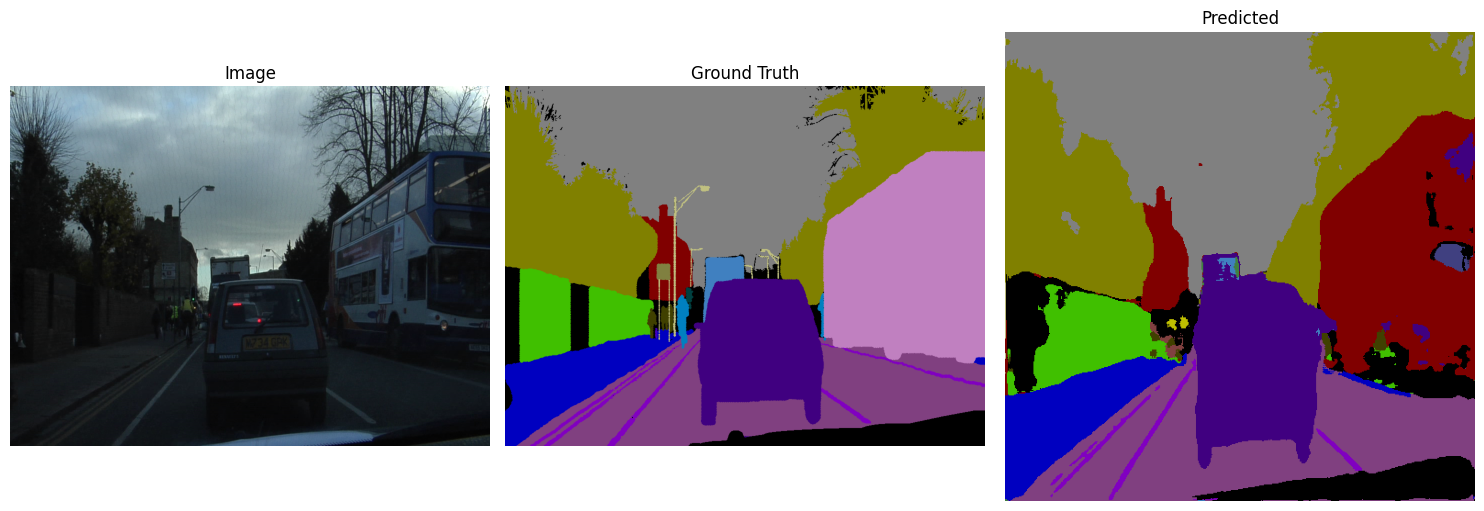

In [9]:
from PIL import Image


state_dict = torch.load('best_model.pth', map_location=torch.device('cpu'), weights_only=True)
model.load_state_dict(state_dict)

def colorize_mask(mask, class_colors):
    color_array = np.array(class_colors, dtype = np.uint8)
    return color_array[mask]

def predict_single_image(model, img_path, mask_path, class_colors, device):
    transform = A.Compose([
        A.Resize(512, 512),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])

    image = np.array(Image.open(img_path).convert("RGB"))
    mask = np.array(Image.open(mask_path).convert("RGB"))
    
    tensor = transform(image=image)["image"].unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        pred = model(tensor).argmax(dim=1).squeeze(0).cpu().numpy()

    pred_colored = colorize_mask(pred, class_colors)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image);          axes[0].set_title("Image");      axes[0].axis("off")
    axes[1].imshow(mask);           axes[1].set_title("Ground Truth"); axes[1].axis("off")
    axes[2].imshow(pred_colored);   axes[2].set_title("Predicted");  axes[2].axis("off")
    plt.tight_layout()

predict_single_image(model, "./CamVid/val/0001TP_009030.png",
                            "./CamVid/val_labels/0001TP_009030_L.png",
                            class_colors, device)